Setting Up Our Quantum Playground

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

Creating Our Test Circuit

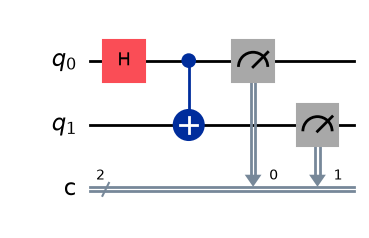

In [2]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply some gates
qc.h(0)           # Hadamard on qubit 0
qc.cx(0, 1)       # CNOT from qubit 0 to qubit 1
qc.measure([0,1], [0,1])  # Measure both qubits

# Draw the circuit
qc.draw('mpl')

Statevector Simulator - The Perfect View

In [3]:
# Create simulator
statevector_sim = AerSimulator(method='statevector')

# Run without measurements to get the statevector
qc_no_measure = QuantumCircuit(2, 2)
qc_no_measure.h(0)
qc_no_measure.cx(0, 1)

# Tell the simulator to store the vector
qc_no_measure.save_statevector()

# Execute
job = statevector_sim.run(qc_no_measure)
result = job.result()
statevector = result.get_statevector()

print("Statevector:", statevector)
print("\nProbabilities:", np.abs(statevector)**2)

Statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Probabilities: [0.5 0.  0.  0.5]


QASM Simulator - The Realistic Approach

In [4]:
# Create simulator
qasm_sim = AerSimulator(method='automatic')

# Run with measurements
job = qasm_sim.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement results:", counts)
print("\nProbabilities from measurement:")
for state, count in counts.items():
    print(f"|{state}>: {count/1024:.3f}")

Measurement results: {'00': 520, '11': 504}

Probabilities from measurement:
|00>: 0.508
|11>: 0.492


Unitary Simlator - The Mathematical Matrix

In [5]:
# Create simulator
unitary_sim = AerSimulator(method='unitary')

# Run without measurements
qc_unitary = QuantumCircuit(2)
qc_unitary.h(0)
qc_unitary.cx(0, 1)

# Tell the simulator to store the unitary matrix
qc_unitary.save_unitary()

job = unitary_sim.run(qc_unitary)
result = job.result()
unitary = result.get_unitary()

print("Unitary matrix of the circuit:")
print(unitary.data.round(3))

Unitary matrix of the circuit:
[[ 0.707+0.j  0.707-0.j  0.   +0.j  0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.707+0.j -0.707+0.j]
 [ 0.   +0.j  0.   +0.j  0.707+0.j  0.707-0.j]
 [ 0.707+0.j -0.707+0.j  0.   +0.j  0.   +0.j]]


Performance Comparison

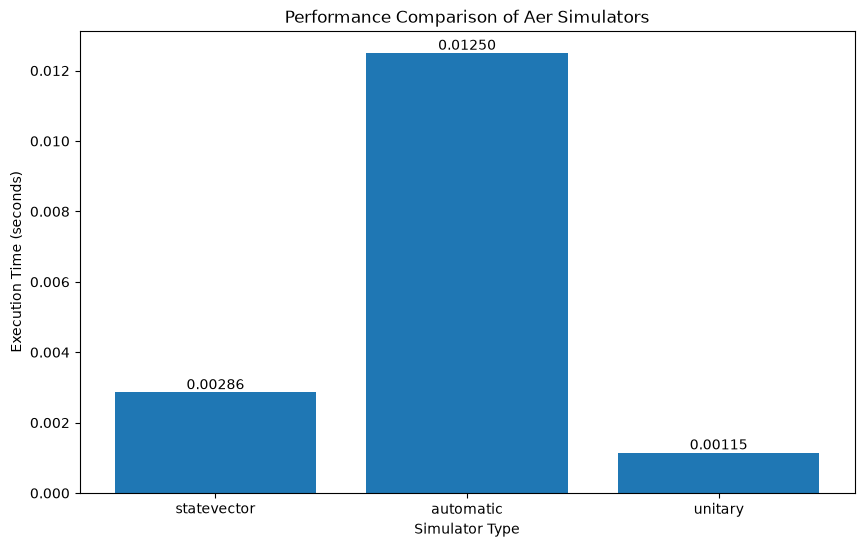

In [6]:
import time
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

# Function to time simulation
def time_simulator(method, shots=1024):
    start = time.time()
    sim = AerSimulator(method=method)
    if method == 'statevector':
        job = sim.run(qc_no_measure)
    elif method == 'unitary':
        job = sim.run(qc_unitary)
    else:
        job = sim.run(qc, shots=shots)
    result = job.result()
    return time.time() - start

# Test all three
methods = ['statevector', 'automatic', 'unitary']
times = [time_simulator(m) for m in methods]

# Create comparison bar chart
plt.figure(figsize=(10, 6))

# 1. Save the bars to a variable
bars = plt.bar(methods, times)

# 2. Add the labels to the bars with 2 decimal places
plt.bar_label(bars, fmt='%.5f') 

plt.xlabel('Simulator Type')
plt.ylabel('Execution Time (seconds)')
plt.title('Performance Comparison of Aer Simulators')
plt.show()